In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('CONVENIENT_global_confirmed_cases.csv')

In [ ]:
df.head()

,Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
0,Province/State,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1/23/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2,1/24/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1/25/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1/26/20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df = df.iloc[1:]

In [ ]:
df.rename(columns={'Country/Region': 'Date'}, inplace=True);

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])


/tmp/ipykernel_11080/3386729631.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')


In [ ]:
df.set_index('Date', inplace=True)


In [ ]:
df.head()


,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2020-01-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df = df.astype(float)


In [ ]:
df['Global_Cases'] = df.sum(axis=1)


In [ ]:
global_series = df['Global_Cases']


In [ ]:
print(global_series.head())


Date
2020-01-23    100.0
2020-01-24    287.0
2020-01-25    493.0
2020-01-26    683.0
2020-01-27    809.0
Name: Global_Cases, dtype: float64


In [ ]:
import matplotlib.pyplot as plt


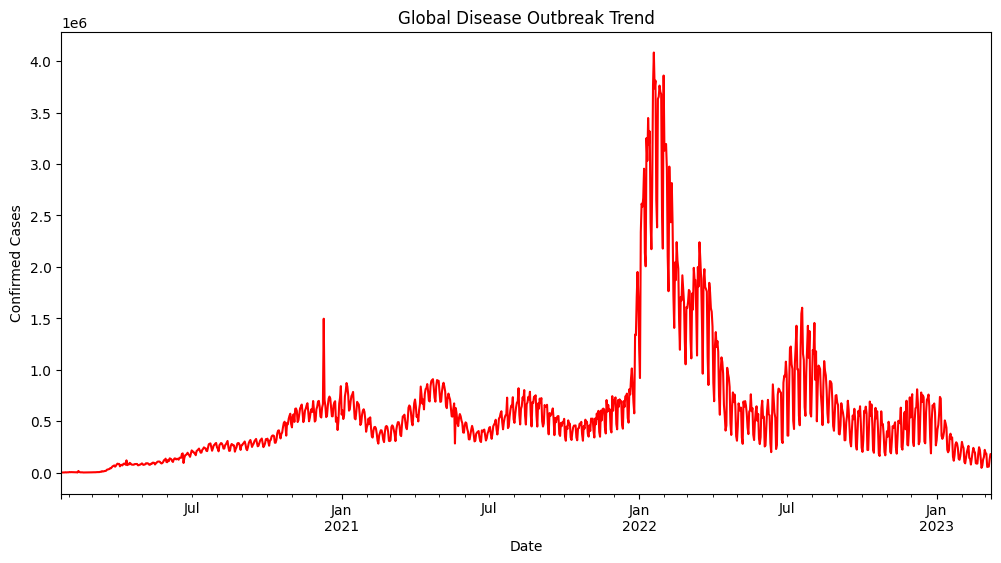

In [ ]:
global_series.plot(title="Global Disease Outbreak Trend", figsize=(12, 6), color='red')
plt.ylabel("Confirmed Cases")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller


In [ ]:
result = adfuller(global_series)


In [ ]:
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -3.044629
p-value: 0.030932


In [ ]:

if result[2] < 0.05:
    print("The data is stationary (Reject Null Hypothesis - Ready for ARIMA).")
else:
    print("The data is non-stationary (Fail to Reject Null - Needs Differencing).")


The data is non-stationary (Fail to Reject Null - Needs Differencing).


In [ ]:

p_value = result[2]


In [ ]:
if p_value < 0.05:
    print(f"p-value is {p_value:.6f}")
    print("The data is stationary (Reject Null Hypothesis - Ready for ARIMA).")
else:
    print(f"p-value is {p_value:.6f}")
    print("The data is non-stationary (Fail to Reject Null - Needs Differencing).")

p-value is 20.000000
The data is non-stationary (Fail to Reject Null - Needs Differencing).


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


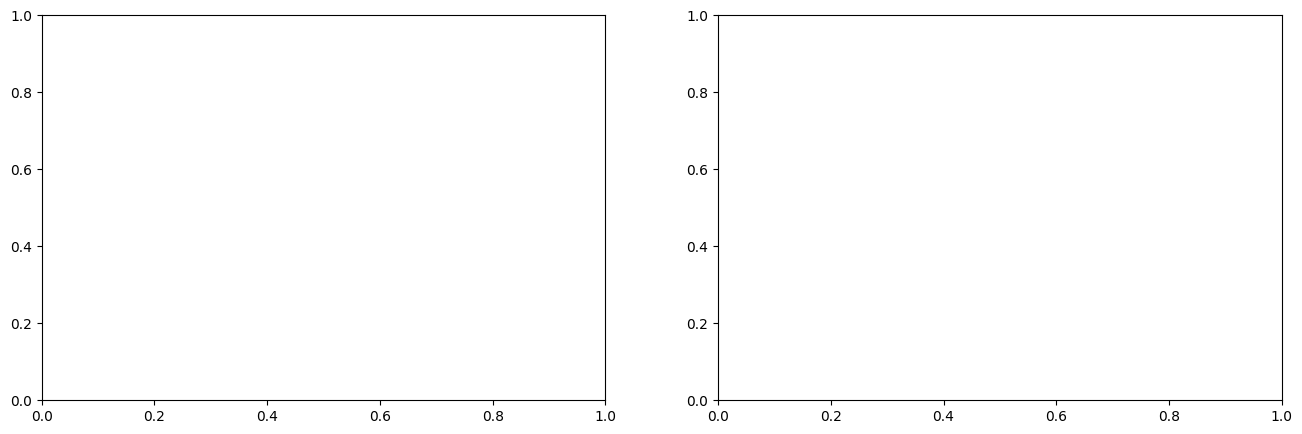

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


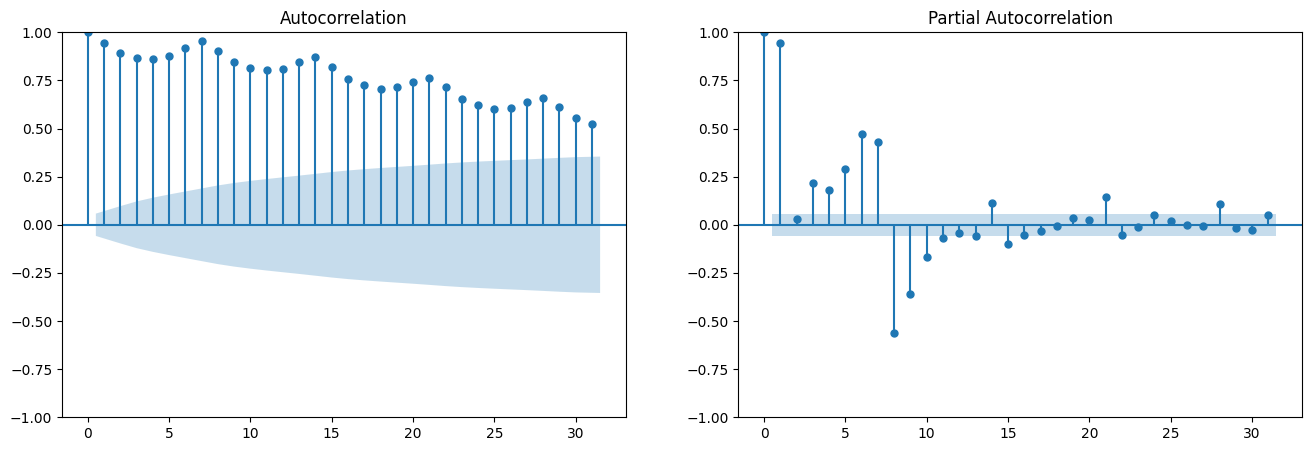

In [ ]:
plot_acf(global_series, ax=axes[0])
plot_pacf(global_series, ax=axes[1])

In [ ]:
plt.show()


In [ ]:
stationary_series = global_series.diff().dropna()


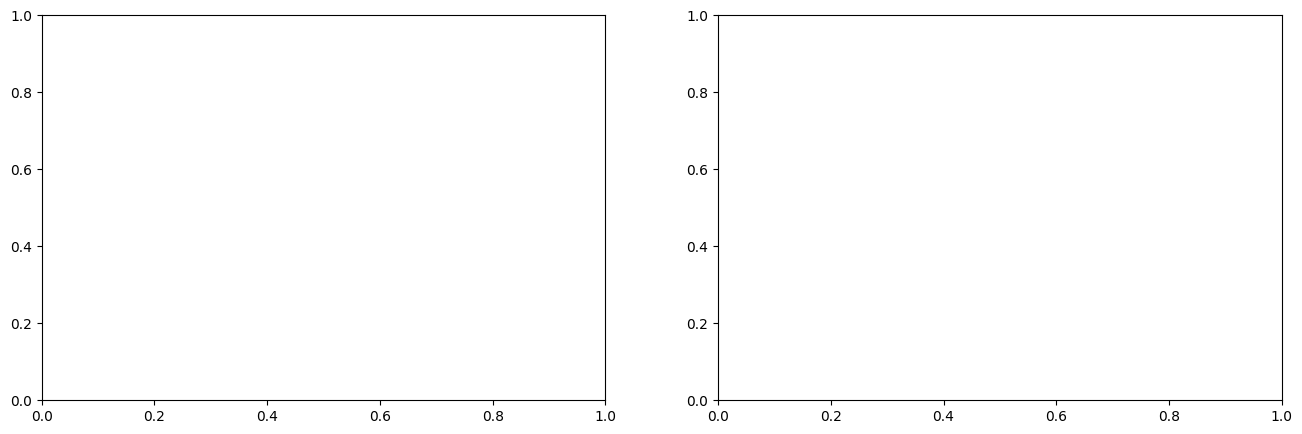

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


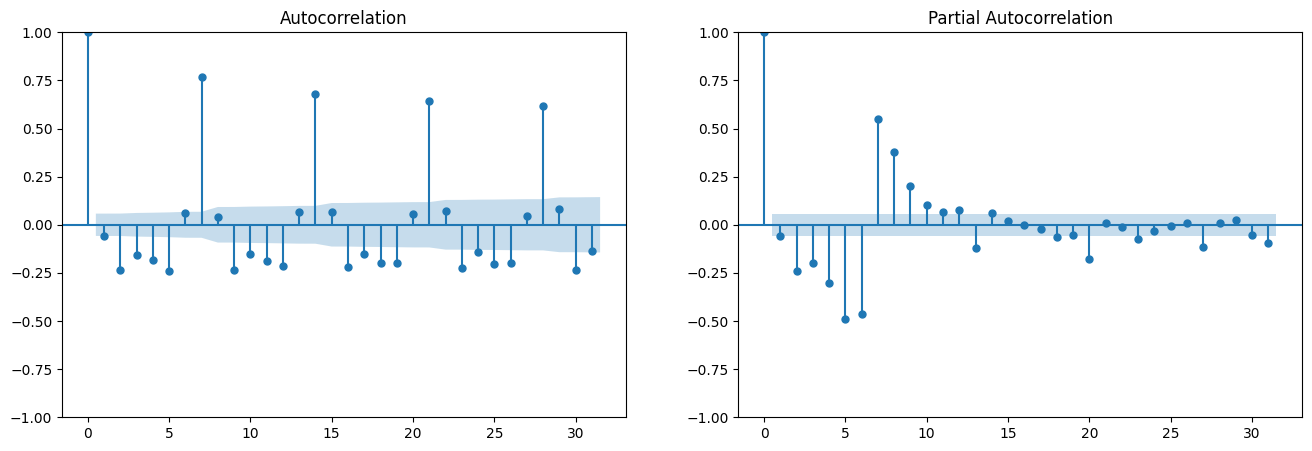

In [ ]:
plot_acf(stationary_series, ax=axes[0])
plot_pacf(stationary_series, ax=axes[1])


In [ ]:
from statsmodels.tsa.arima.model import ARIMA


In [ ]:
# We use (7, 1, 1) based on the clear 7-day seasonal spikes in your plots
# p=7 (weekly lag), d=1 (differencing), q=1 (moving average)
model = ARIMA(global_series, order=(7, 1, 1))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
global_series.index.freq = 'D'


In [ ]:
model_fit = model.fit()


In [ ]:
forecast_steps = 14
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_values = forecast.predicted_mean

In [ ]:
print("Projected Case Counts for the next 14 days:")
print(forecast_values)

Projected Case Counts for the next 14 days:
2023-03-10    150135.129659
2023-03-11     49253.605518
2023-03-12     38530.930703
2023-03-13     49367.158419
2023-03-14    111447.647444
2023-03-15    158059.681801
2023-03-16    160062.838526
2023-03-17    127432.306733
2023-03-18     45152.519539
2023-03-19     28239.594563
2023-03-20     43163.939303
2023-03-21     97871.582272
2023-03-22    141785.532391
2023-03-23    145731.654227
Freq: D, Name: predicted_mean, dtype: float64


In [ ]:
import matplotlib.pyplot as plt


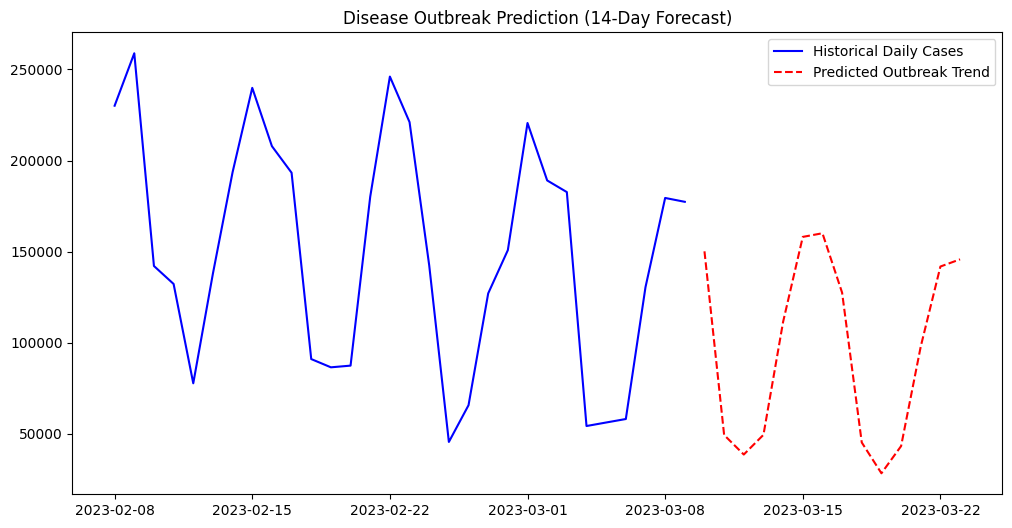

In [ ]:
# Plot the last 30 days of real data and the 14-day forecast
plt.figure(figsize=(12, 6))
plt.plot(global_series.tail(30), label='Historical Daily Cases', color='blue')
plt.plot(forecast_values, label='Predicted Outbreak Trend', color='red', linestyle='--')
plt.title("Disease Outbreak Prediction (14-Day Forecast)")
plt.legend()
plt.show()

In [ ]:
import joblib


In [ ]:
joblib.dump(model_fit, 'arima_outbreak_model.pkl')


['arima_outbreak_model.pkl']

In [ ]:
print("Success: Your model is now saved and ready for deployment!")


Success: Your model is now saved and ready for deployment!


In [ ]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 79.9 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# 1. Dashboard Title
st.title("🌐 Disease Outbreak Prediction Dashboard")
st.write("This tool uses an **ARIMA(7,1,1)** model to forecast future global case counts.")

# 2. Load the saved model (Make sure you ran the 'joblib.dump' step earlier!)
try:
    model = joblib.load('arima_outbreak_model.pkl')
    st.success("Model loaded successfully!")
except Exception as e:
    st.error(f"Error loading model: {e}")
    st.stop() # Stop if model can't be loaded

# 3. User Input
days = st.slider("Select the number of days to forecast:", 1, 30, 14)
st.info(f"Forecasting for {days} days.")

# 4. Generate the Forecast
try:
    forecast = model.forecast(steps=days)
    st.success("Forecast generated successfully!")
    st.write("Forecast Data Head:", forecast.head())
except Exception as e:
    st.error(f"Error generating forecast: {e}")
    st.stop() # Stop if forecast can't be generated

# 5. Visualize
st.subheader(f"Projected Outbreak for the Next {days} Days")
if not forecast.empty:
    st.line_chart(forecast)
else:
    st.warning("Forecast data is empty, cannot display chart.")


Writing app.py


In [ ]:
!streamlit run app.py



2026-05-05 15:59:11.483 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.111.230.233:8501

  Stopping...


In [ ]:
from google.colab import files
# Try to download a fake file first to "wake up" the downloader
try:
    files.download('non_existent_file.txt')
except:
    # Now try your actual file
    files.download('arima_outbreak_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.50.162.4:8502

  Stopping...
  Stopping...


In [ ]:
!
!pip freeze > requirements.txt
print('requirements.txt has been generated.')

requirements.txt has been generated.


In [ ]:
import pandas as pd

# 1. Create a supervised learning dataset [2]
ml_data = pd.DataFrame(global_series)
ml_data.columns = ['Today_Cases']

# 2. Create 'Lag_1' (Yesterday's Cases) as our feature [X]
ml_data['Yesterday_Cases'] = ml_data['Today_Cases'].shift(1)

# 3. Drop the first row which will have a NaN value
ml_data.dropna(inplace=True)

X = ml_data[['Yesterday_Cases']] # Feature
y = ml_data['Today_Cases']      # Target

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split data (80% training, 20% testing) [4]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
# 1. Initialize and Train the Model [3, 4]
ml_model = LinearRegression()
ml_model.fit(X_train, y_train)

# 2. Make Predictions [4]
y_pred = ml_model.predict(X_test)

# 3. Evaluate using Rubric Metrics [1, 4]
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

Mean Squared Error: 30255999342.722622
R-squared Score: 0.6079622189255698


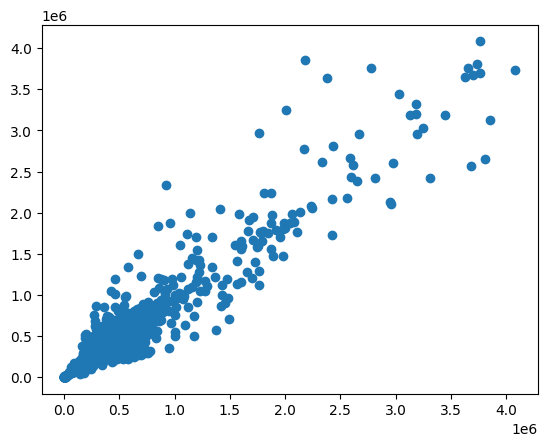

In [ ]:
plt.scatter(ml_data['Yesterday_Cases'], ml_data['Today_Cases'])

<Axes: >

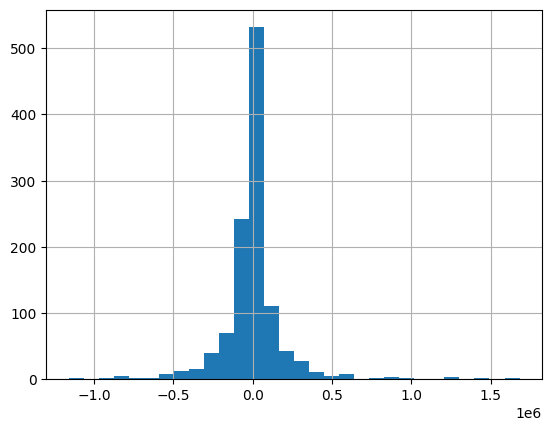

In [ ]:
 global_series.diff().hist(bins=30)


In [ ]:
ml_data['Lag_2'] = ml_data['Today_Cases'].shift(2)

<Axes: >

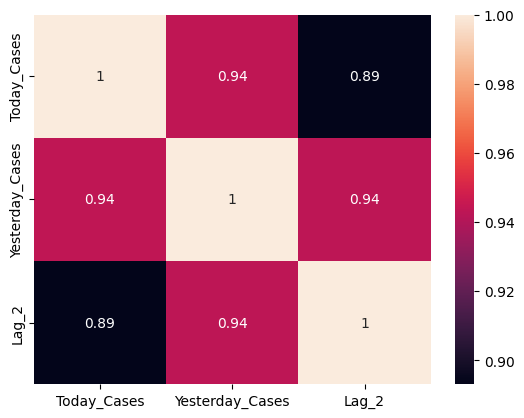

In [ ]:
import seaborn as sns
sns.heatmap(ml_data.corr(), annot=True)